# EDA - Open Exoplanet Catalogue

Цель: классификация экзопланет по физическому типу (`terrestrial`, `neptunian`, `gas_giant`).
Метки выводятся из массы (Jupiter masses) и радиуса (Jupiter radii) - поэтому эти признаки удаляются из X.

In [13]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.preprocessing import (
    CLASS_LABELS,
    TARGET_COL,
    add_engineered_features,
    add_target,
    load_raw_data,
    save_processed,
    clean_data,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

## 1. Загрузка данных и общий обзор

In [14]:
df_raw = load_raw_data()
print("shape:", df_raw.shape)
df_raw.head()

shape: (3584, 25)


,PlanetIdentifier,TypeFlag,PlanetaryMassJpt,RadiusJpt,PeriodDays,SemiMajorAxisAU,Eccentricity,PeriastronDeg,LongitudeDeg,AscendingNodeDeg,InclinationDeg,SurfaceTempK,AgeGyr,DiscoveryMethod,DiscoveryYear,LastUpdated,RightAscension,Declination,DistFromSunParsec,HostStarMassSlrMass,HostStarRadiusSlrRad,HostStarMetallicity,HostStarTempK,HostStarAgeGyr,ListsPlanetIsOn
0,HD 143761 b,0,1.0450,NaN,39.845800,0.2196,0.037,270.6,NaN,NaN,NaN,NaN,NaN,RV,2016.0,16/07/11,16 01 03,+33 18 13,17.236,0.889,1.362,-0.31,5627.0,NaN,Confirmed planets
1,HD 143761 c,0,0.0790,NaN,102.540000,0.4123,0.050,190.0,NaN,NaN,NaN,NaN,NaN,RV,2016.0,16/07/11,16 01 03,+33 18 13,17.236,0.889,1.362,-0.31,5627.0,NaN,Confirmed planets
2,KOI-1843.03,0,0.0014,0.054,0.176891,0.0048,NaN,NaN,NaN,NaN,72.00,NaN,NaN,transit,2012.0,13/07/15,19 00 03.14,+40 13 14.7,NaN,0.460,0.450,0.00,3584.0,NaN,Controversial
3,KOI-1843.01,0,NaN,0.114,4.194525,0.0390,NaN,NaN,NaN,NaN,89.38,NaN,NaN,transit,NaN,NaN,19 00 03.14,+40 13 14.7,NaN,0.460,0.450,0.00,3584.0,NaN,Controversial
4,KOI-1843.02,0,NaN,0.071,6.356006,0.0520,NaN,NaN,NaN,NaN,88.24,NaN,NaN,transit,NaN,NaN,19 00 03.14,+40 13 14.7,NaN,0.460,0.450,0.00,3584.0,NaN,Controversial


In [15]:
df_raw.dtypes

PlanetIdentifier            str
TypeFlag                  int64
PlanetaryMassJpt        float64
RadiusJpt               float64
PeriodDays              float64
SemiMajorAxisAU         float64
Eccentricity            float64
PeriastronDeg           float64
LongitudeDeg            float64
AscendingNodeDeg        float64
InclinationDeg          float64
SurfaceTempK            float64
AgeGyr                  float64
DiscoveryMethod             str
DiscoveryYear           float64
LastUpdated                 str
RightAscension              str
Declination                 str
DistFromSunParsec       float64
HostStarMassSlrMass     float64
HostStarRadiusSlrRad    float64
HostStarMetallicity     float64
HostStarTempK           float64
HostStarAgeGyr          float64
ListsPlanetIsOn             str
dtype: object

## 2. Пропуски и дубликаты

In [16]:
missing = (df_raw.isna().mean() * 100).round(1).sort_values(ascending=False)
print("duplicates by PlanetIdentifier:", df_raw.duplicated(subset=["PlanetIdentifier"]).sum())
missing.to_frame("missing_%")

duplicates by PlanetIdentifier: 2


,missing_%
AgeGyr,99.9
LongitudeDeg,98.8
AscendingNodeDeg,98.7
PeriastronDeg,90.8
HostStarAgeGyr,85.6
InclinationDeg,81.4
SurfaceTempK,79.3
Eccentricity,69.1
PlanetaryMassJpt,63.4
SemiMajorAxisAU,60.8


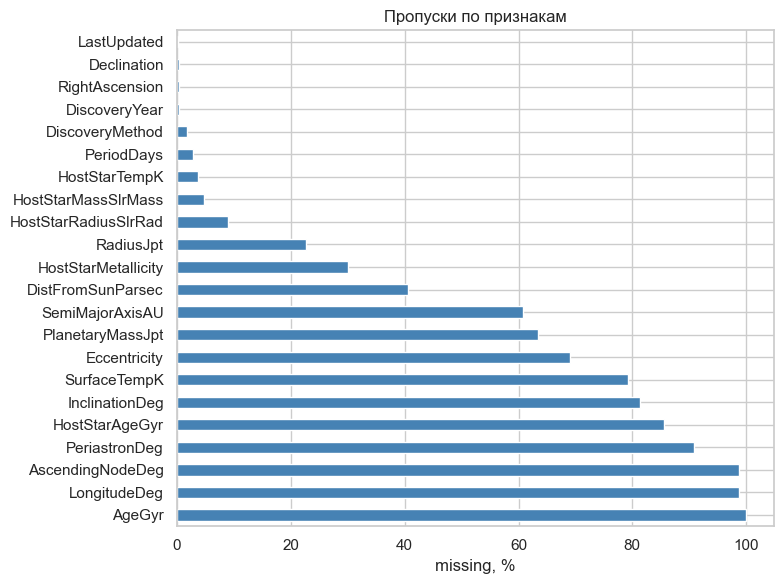

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
missing[missing > 0].plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("missing, %")
ax.set_title("Пропуски по признакам")
plt.tight_layout()
plt.show()

## 3. Целевая переменная

Из массы (Mjup) и радиуса (Rjup) формируем 3 класса:
- `terrestrial`: M < 0.03 Mjup или R < 0.18 Rjup
- `neptunian`: 0.03 ≤ M < 0.15 Mjup или 0.18 ≤ R < 0.5 Rjup
- `gas_giant`: остальное

Метрика - **F1-macro** (классы примерно сбалансированы, но интересен качественный отлов всех типов).

PlanetClass
neptunian      1241
terrestrial    1221
gas_giant      1106
NaN              16
Name: count, dtype: int64


/var/folders/7k/vqdft2t91t9dztdv_0k3gqp80000gn/T/ipykernel_96832/3096425413.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


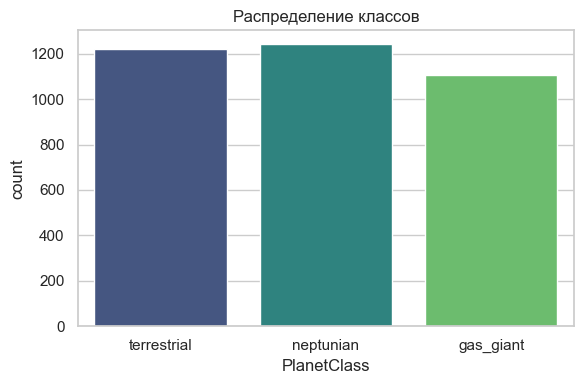

In [18]:
df_lab = add_target(df_raw)
print(df_lab[TARGET_COL].value_counts(dropna=False))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(
    data=df_lab.dropna(subset=[TARGET_COL]),
    x=TARGET_COL,
    order=CLASS_LABELS,
    ax=ax,
    palette="viridis",
)
ax.set_title("Распределение классов")
plt.tight_layout()
plt.show()

## 4. Распределения и выбросы

In [19]:
numeric_eda = [
    "PeriodDays",
    "SemiMajorAxisAU",
    "Eccentricity",
    "InclinationDeg",
    "HostStarMassSlrMass",
    "HostStarRadiusSlrRad",
    "HostStarMetallicity",
    "HostStarTempK",
    "DistFromSunParsec",
]
df_lab[numeric_eda].describe().T

,count,mean,std,min,25%,50%,75%,max
PeriodDays,3485.0,537.248317,7509.660676,0.090706,4.75794,13.07163,49.514000,320000.000
SemiMajorAxisAU,1406.0,2.000170,19.352699,0.004420,0.05300,0.16950,1.250000,662.000
Eccentricity,1108.0,0.166910,0.189760,0.000000,0.02000,0.10000,0.247282,0.956
InclinationDeg,665.0,82.973840,21.402768,-0.000543,85.05800,87.80000,89.140000,305.000
HostStarMassSlrMass,3416.0,0.983225,0.319063,0.012000,0.83000,0.97700,1.105000,4.500
HostStarRadiusSlrRad,3263.0,1.495629,3.071298,0.000014,0.81000,1.00000,1.250000,51.100
HostStarMetallicity,2509.0,0.016228,0.193495,-2.090000,-0.05000,0.02000,0.100000,0.560
HostStarTempK,3455.0,5505.514501,1204.271777,540.000000,5113.00000,5634.00000,5940.000000,29300.000
DistFromSunParsec,2133.0,554.912346,847.566803,1.295000,60.00000,333.00000,773.130000,8500.000


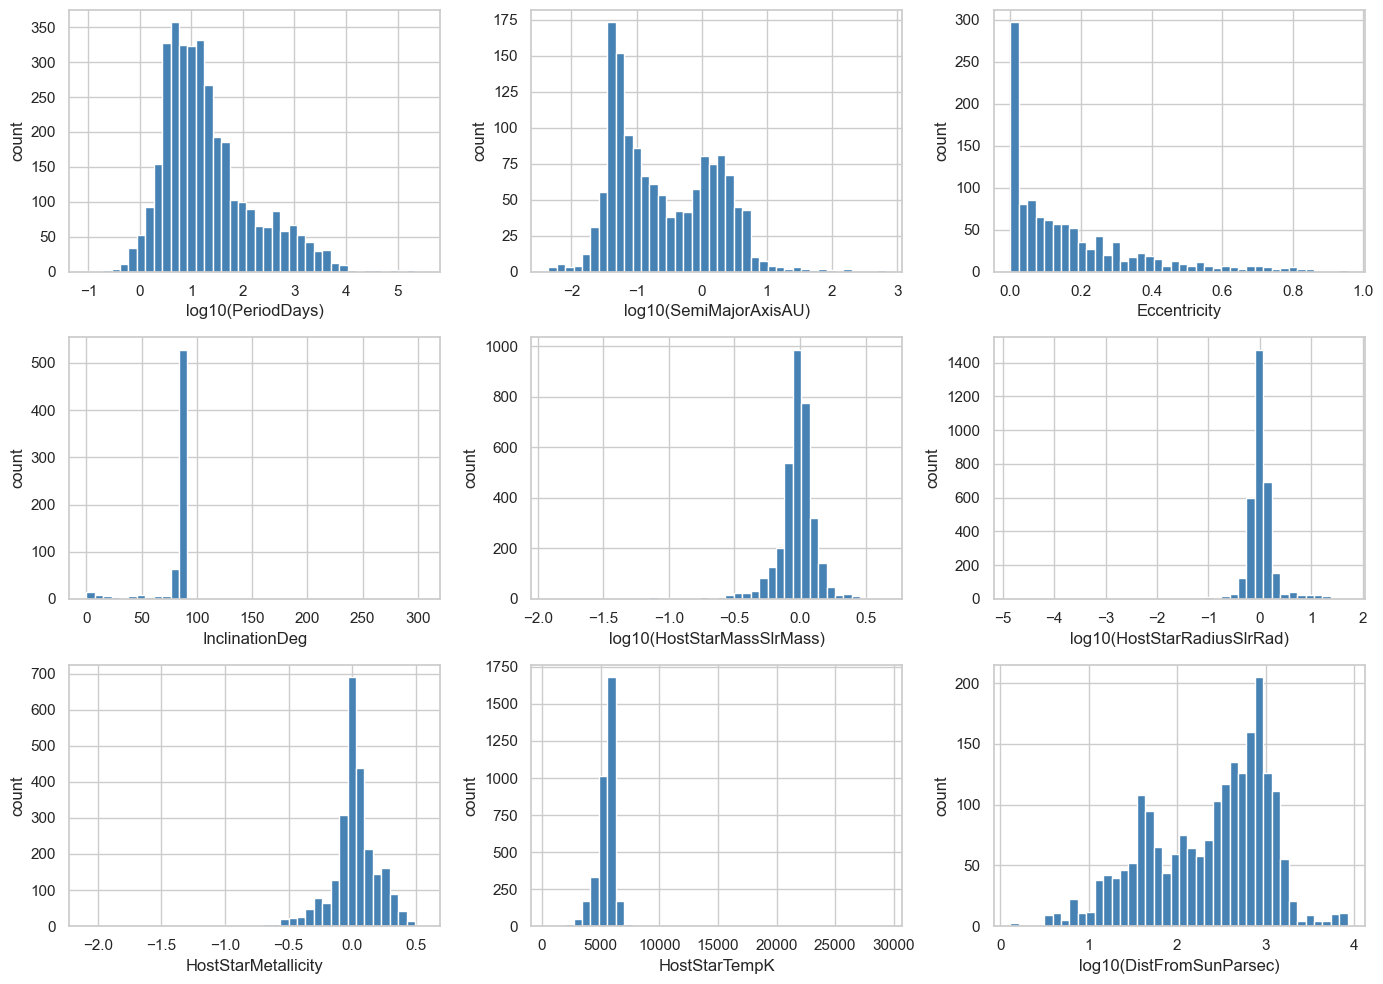

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), numeric_eda):
    series = df_lab[col].dropna()
    if (series > 0).all() and series.max() / max(series.min(), 1e-9) > 100:
        ax.hist(np.log10(series + 1e-9), bins=40, color="steelblue")
        ax.set_xlabel(f"log10({col})")
    else:
        ax.hist(series, bins=40, color="steelblue")
        ax.set_xlabel(col)
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## 5. Зависимости признаков от класса

/var/folders/7k/vqdft2t91t9dztdv_0k3gqp80000gn/T/ipykernel_96832/2228411332.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/7k/vqdft2t91t9dztdv_0k3gqp80000gn/T/ipykernel_96832/2228411332.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/7k/vqdft2t91t9dztdv_0k3gqp80000gn/T/ipykernel_96832/2228411332.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/7k/vqdft2t91t9dztdv_0k3gqp80000gn/T/ipykernel_96832/2228411332.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated an

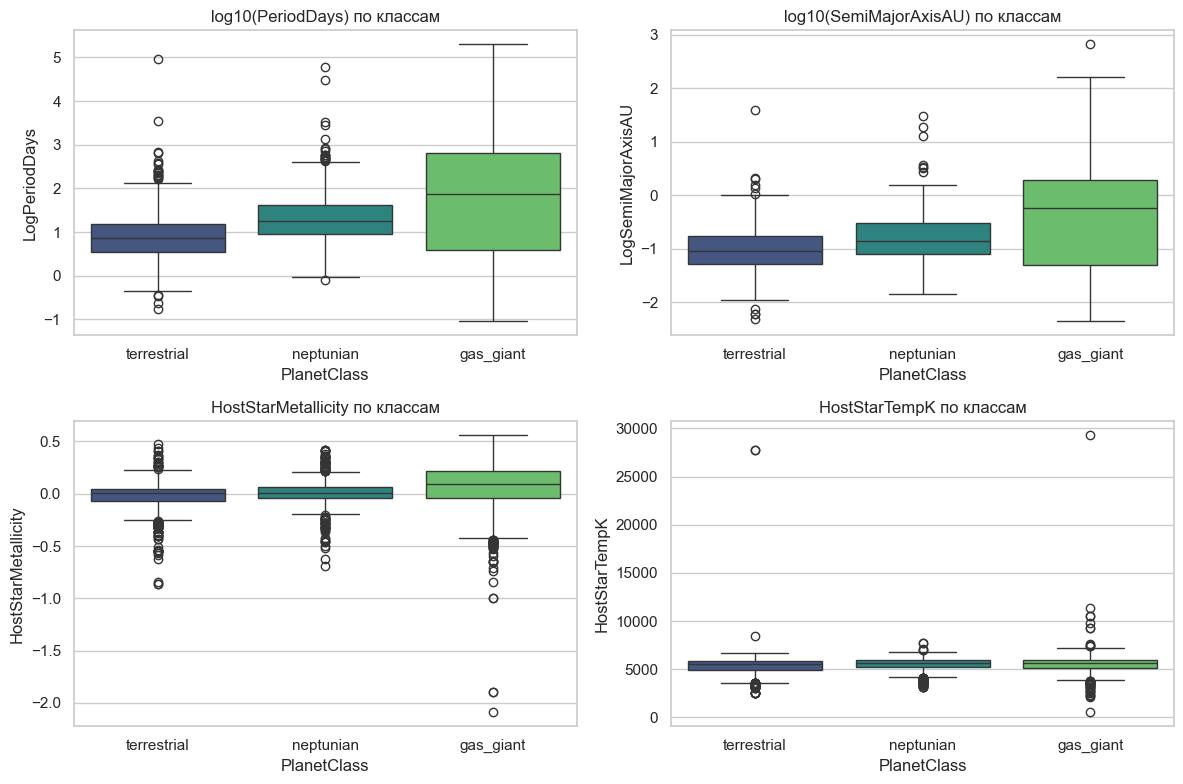

In [21]:
df_plot = df_lab.dropna(subset=[TARGET_COL]).copy()
df_plot["LogPeriodDays"] = np.log10(df_plot["PeriodDays"].clip(lower=1e-3))
df_plot["LogSemiMajorAxisAU"] = np.log10(df_plot["SemiMajorAxisAU"].clip(lower=1e-4))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(
    data=df_plot, x=TARGET_COL, y="LogPeriodDays", order=CLASS_LABELS,
    ax=axes[0, 0], palette="viridis",
)
axes[0, 0].set_title("log10(PeriodDays) по классам")

sns.boxplot(
    data=df_plot, x=TARGET_COL, y="LogSemiMajorAxisAU", order=CLASS_LABELS,
    ax=axes[0, 1], palette="viridis",
)
axes[0, 1].set_title("log10(SemiMajorAxisAU) по классам")

sns.boxplot(
    data=df_plot, x=TARGET_COL, y="HostStarMetallicity", order=CLASS_LABELS,
    ax=axes[1, 0], palette="viridis",
)
axes[1, 0].set_title("HostStarMetallicity по классам")

sns.boxplot(
    data=df_plot, x=TARGET_COL, y="HostStarTempK", order=CLASS_LABELS,
    ax=axes[1, 1], palette="viridis",
)
axes[1, 1].set_title("HostStarTempK по классам")

plt.tight_layout()
plt.show()

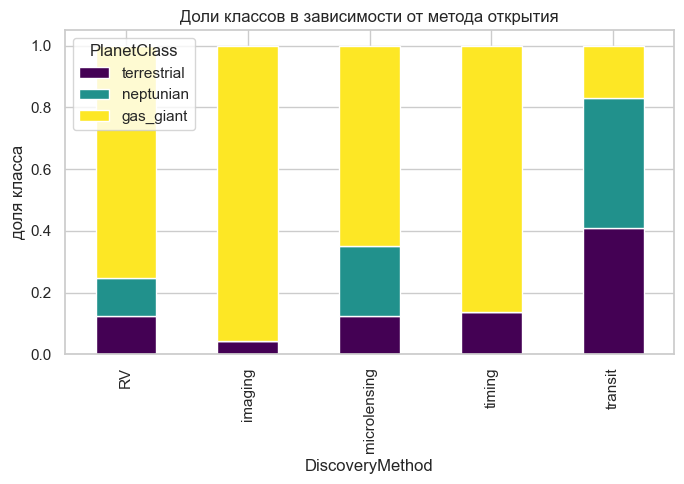

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
ct = pd.crosstab(df_plot["DiscoveryMethod"], df_plot[TARGET_COL], normalize="index")
ct = ct[CLASS_LABELS]
ct.plot.bar(stacked=True, ax=ax, colormap="viridis")
ax.set_ylabel("доля класса")
ax.set_title("Доли классов в зависимости от метода открытия")
plt.tight_layout()
plt.show()

## 6. Корреляции

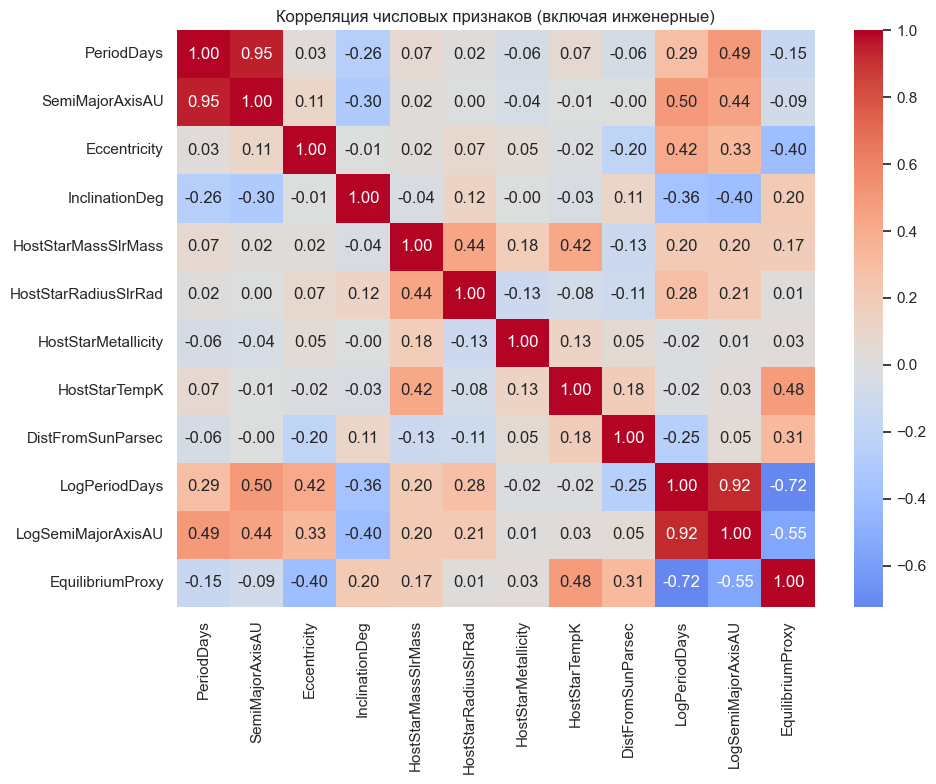

In [23]:
df_eng = add_engineered_features(df_lab.dropna(subset=[TARGET_COL]).copy())
corr_cols = numeric_eda + ["LogPeriodDays", "LogSemiMajorAxisAU", "EquilibriumProxy"]
corr = df_eng[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Корреляция числовых признаков (включая инженерные)")
plt.tight_layout()
plt.show()

## 7. Сохранение очищенного датасета

In [24]:
df_clean = clean_data(df_raw)
print("clean shape:", df_clean.shape)
print(df_clean[TARGET_COL].value_counts())
out = save_processed(df_clean, "oec_clean.csv")
print("saved to:", out)

clean shape: (3566, 16)
PlanetClass
neptunian      1240
terrestrial    1220
gas_giant      1106
Name: count, dtype: int64
saved to: /Users/georgepust/Desktop/university/3/ml/project/hseml-group-project-vivatttt/data/processed/oec_clean.csv
